# AMIA multi-label chest X-ray classification

This notebook trains a **multi-label image classifier** with a pretrained ResNet-18.

Important scope:
- The model predicts which findings are present in an image.
- Bounding-box coordinates are inspected but are **not** used.
- This is therefore classification, not object detection.


In [165]:
import os
import random
import time
from pathlib import Path
import json
import torchvision 
import sys 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import sklearn
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
    roc_auc_score)

from sklearn.utils.multiclass import type_of_target

def set_seed(seed: int = 43) -> None:
    """Make the main random operations reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility can reduce performance slightly, but makes runs comparable
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


RANDOM_STATE = 44
set_seed(RANDOM_STATE)

### print versions
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)


Python: 3.12.2 | packaged by Anaconda, Inc. | (main, Feb 27 2024, 17:28:07) [MSC v.1916 64 bit (AMD64)]
NumPy: 1.26.4
scikit-learn: 1.3.0
PyTorch: 2.13.0+cpu
torchvision: 0.28.0+cpu


## Configuration

In [117]:
base_dir = "data"
train_dir = os.path.join(base_dir, "train")
train_meta_path = os.path.join(base_dir, "train.csv")

results_dir = "results"
output_dir = os.path.join(results_dir, "outputs")
EXPERIMENT_NAME = "B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP"
checkpoint_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_checkpoint.pth")
loss_plot_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_loss.png")

#VAL_RATIO = 0.20
BATCH_SIZE = 32
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4

#HEAD_LEARNING_RATE = 1e-3
HEAD_LEARNING_RATE = 5e-4
#BACKBONE_LEARNING_RATE = 1e-5
BACKBONE_LEARNING_RATE = 2e-5
EARLY_BACKBONE_LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
# DROPOUT_RATE = 0.3

NUM_WORKERS = 0

# True: train the final ResNet block and classification head.
# False: train only the classification head, which is faster on CPU.
FINE_TUNE_LAYER3 = True
FINE_TUNE_LAYER4 = True
FINE_TUNE_LAYER1 = True
FINE_TUNE_LAYER2 = True
FULL_FINE_TUNING = True

ARCHITECTURE = "efficientnet_b0"
#ARCHITECTURE = "resnet18"
IMAGE_SIZE = 320

MAX_POS_WEIGHT = 10.0

#FINE_TUNE_BLOCK3 = True
#FINE_TUNE_BLOCK4 = True

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

os.makedirs(output_dir, exist_ok=True)

print("Metadata:", train_meta_path)
print("Device:", device)
print("Output directory:", output_dir)


Metadata: data\train.csv
Device: cpu
Output directory: results\outputs


## Load metadata and class names

In [118]:
train_meta = pd.read_csv(train_meta_path)

required_columns = {"image_id", "class_id", "class_name"}
missing_columns = required_columns - set(train_meta.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

train_meta["class_id"] = train_meta["class_id"].astype(int)

full_class_table = (train_meta[["class_id", "class_name"]].drop_duplicates().sort_values("class_id").reset_index(drop=True))

display(full_class_table)

print("Metadata rows:", len(train_meta))
print("Unique images:", train_meta["image_id"].nunique())


,class_id,class_name
0,0,Aortic enlargement
1,1,Atelectasis
2,2,Calcification
3,3,Cardiomegaly
4,4,Consolidation
5,5,ILD
6,6,Infiltration
7,7,Lung Opacity
8,8,Nodule/Mass
9,9,Other lesion


Metadata rows: 45925
Unique images: 8573


## Inspect missing bounding boxes

For `No finding`, missing bounding-box coordinates are expected because there is no abnormal region to localize. These rows are therefore not removed.


In [119]:
box_columns = ["x_min", "y_min", "x_max", "y_max"]
available_box_columns = [column for column in box_columns if column in train_meta.columns]

if available_box_columns:
    missing_boxes_by_class = (train_meta.groupby("class_name")[available_box_columns].apply(lambda frame: frame.isna().sum()))
    display(missing_boxes_by_class)

    rows_without_complete_box = train_meta[available_box_columns].isna().any(axis=1)
    print("Rows without a complete bounding box:", rows_without_complete_box.sum())
else:
    print("No bounding-box columns were found.")


,x_min,y_min,x_max,y_max
class_name,,,,
Aortic enlargement,0,0,0,0
Atelectasis,0,0,0,0
Calcification,0,0,0,0
Cardiomegaly,0,0,0,0
Consolidation,0,0,0,0
ILD,0,0,0,0
Infiltration,0,0,0,0
Lung Opacity,0,0,0,0
No finding,15525,15525,15525,15525


Rows without a complete bounding box: 15525


## Build image-level multi-label targets

All annotations belonging to an image are combined into one set of labels.

A contradiction can occur when one radiologist assigns `No finding` while another assigns a pathological finding.

`No finding` is not included as a separate model output. Images annotated only as `No finding` remain in the training set with an all-zero disease-label vector. During inference, `No finding` is derived when none of the 14 disease classes is predicted.

In [120]:
# Identify the No-finding class
no_finding_matches = full_class_table[full_class_table["class_name"].str.strip().str.lower().eq("no finding")]

if len(no_finding_matches) != 1:
    raise ValueError("The class 'No finding' could not be identified uniquely")

NO_FINDING_ID = int(no_finding_matches.iloc[0]["class_id"])

# Keep only pathological classes as model outputs
class_table = (full_class_table[full_class_table["class_id"] != NO_FINDING_ID].sort_values("class_id").reset_index(drop=True))

class_names = class_table["class_name"].tolist()
NUM_CLASSES = len(class_table)

# Map original CSV class IDs to model output positions 0–13
class_id_to_index = {
    int(original_class_id): model_index
    for model_index, original_class_id
    in enumerate(class_table["class_id"])}

image_labels = {}

for image_id, group in train_meta.groupby("image_id",sort=False):
    original_labels = set(group["class_id"].astype(int))

    # No finding is never used as a model target
    original_labels.discard(NO_FINDING_ID)

    disease_labels = {class_id_to_index[class_id]
        for class_id in original_labels
        if class_id in class_id_to_index}

    # For a No-finding image, this is an empty set.
    # The image remains in training as an all-zero target.
    image_labels[image_id] = disease_labels

image_ids = sorted(image_labels)

number_no_finding_images = sum(len(labels) == 0 for labels in image_labels.values())

print("Original No-finding class ID:", NO_FINDING_ID)
print("Predicted disease classes:", NUM_CLASSES)
print("Unique images:", len(image_ids))
print("Images represented by an all-zero target:", number_no_finding_images)

display(class_table)


Original No-finding class ID: 14
Predicted disease classes: 14
Unique images: 8573
Images represented by an all-zero target: 5175


,class_id,class_name
0,0,Aortic enlargement
1,1,Atelectasis
2,2,Calcification
3,3,Cardiomegaly
4,4,Consolidation
5,5,ILD
6,6,Infiltration
7,7,Lung Opacity
8,8,Nodule/Mass
9,9,Other lesion


## Create a balanced train/validation/test split

A plain random split can produce noticeably different prevalences for rare labels. A fixed 70/15/15 training, validation, and test split is created.  
The split approximately balances the prevalence of all pathological
classes and the derived `No finding` category.

This is a dependency-free approximation to iterative multi-label stratification.


In [121]:
def build_label_matrix(image_id_list, labels_by_image, num_classes):
    matrix = np.zeros((len(image_id_list), num_classes), dtype=np.float32)

    for row_index, image_id in enumerate(image_id_list):
        for class_id in labels_by_image[image_id]:
            matrix[row_index, class_id] = 1.0

    return matrix


def build_split_matrix(image_id_list,labels_by_image,num_classes):
    """
    Create a matrix used only for balancing the data split.

    In addition to the 14 disease classes, an extra column represents
    No finding, defined as the absence of all disease labels.
    """
    disease_matrix = build_label_matrix(image_id_list,labels_by_image,num_classes)

    no_finding = (disease_matrix.sum(axis=1) == 0).astype(np.float32).reshape(-1, 1)

    return np.hstack([disease_matrix,no_finding])

def create_balanced_multilabel_split(image_id_list,labels_by_image,num_classes,val_ratio=0.2,random_state=42,trials=300,):
    """
    Select a reproducible random split with similar prevalences
    for all disease classes and for No finding.
    """
    ids = np.asarray(image_id_list)

    # Includes 14 disease columns plus one No-finding column
    split_targets = build_split_matrix(ids,labels_by_image,num_classes)

    n_samples = len(ids)
    n_val = int(round(n_samples * val_ratio))

    rng = np.random.default_rng(random_state)

    best_score = np.inf
    best_train_indices = None
    best_val_indices = None

    total_positives = split_targets.sum(axis=0)

    for _ in range(trials):
        val_indices = rng.choice(n_samples,size=n_val,replace=False)

        val_mask = np.zeros(n_samples,dtype=bool)
        val_mask[val_indices] = True

        train_indices = np.flatnonzero(~val_mask)

        train_targets = split_targets[train_indices]
        val_targets = split_targets[val_indices]

        train_prevalence = train_targets.mean(axis=0)
        val_prevalence = val_targets.mean(axis=0)

        prevalence_difference = np.abs(train_prevalence - val_prevalence).mean()

        # Penalize splits in which a class is completely absent
        missing_train = ((train_targets.sum(axis=0) == 0) & (total_positives > 0)).sum()

        missing_val = ((val_targets.sum(axis=0) == 0) & (total_positives > 0)).sum()

        score = (prevalence_difference + missing_train + missing_val)

        if score < best_score:
            best_score = score
            best_train_indices = train_indices
            best_val_indices = val_indices

    train_ids = ids[best_train_indices].tolist()

    val_ids = ids[best_val_indices].tolist()

    return train_ids, val_ids

split_path = os.path.join(output_dir,"baseline_split.csv")

if os.path.exists(split_path):
    print("Loading existing baseline split:", split_path)

    split_table = pd.read_csv(split_path)
    train_ids = split_table.loc[split_table["split"] == "train","image_id"].tolist()
    val_ids = split_table.loc[split_table["split"] == "validation","image_id"].tolist()
    test_ids = split_table.loc[split_table["split"] == "test","image_id"].tolist()

else:
    print("Creating new baseline split")

    # Separate an untouched test set containing 15% of all images
    development_ids, test_ids = create_balanced_multilabel_split(image_ids,image_labels,NUM_CLASSES,val_ratio=0.15, random_state=42)

    # Select another 15% of the complete dataset as validation
    train_ids, val_ids = create_balanced_multilabel_split(development_ids,image_labels,NUM_CLASSES,val_ratio=0.15 / 0.85,random_state=43)

    split_table = pd.concat(
        [pd.DataFrame({
                "image_id": train_ids,
                "split": "train"}),
            pd.DataFrame({
                "image_id": val_ids,
                "split": "validation"}),
            pd.DataFrame({
                "image_id": test_ids,
                "split": "test"}),
        ],ignore_index=True,)

    split_table.to_csv(split_path,index=False,)

    print("Split saved to:", split_path)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))
print("Total:", len(train_ids) + len(val_ids) + len(test_ids))


train_label_matrix = build_label_matrix(train_ids,image_labels,NUM_CLASSES)
val_label_matrix = build_label_matrix(val_ids,image_labels,NUM_CLASSES)
test_label_matrix = build_label_matrix(test_ids,image_labels,NUM_CLASSES)

distribution_table = pd.DataFrame({"class_id": range(NUM_CLASSES),"class_name": class_names,

    "train_positive": (train_label_matrix.sum(axis=0).astype(int)),
    "validation_positive": (val_label_matrix.sum(axis=0).astype(int)),
    "test_positive": (test_label_matrix.sum(axis=0).astype(int)),

    "train_prevalence": (train_label_matrix.mean(axis=0)),
    "validation_prevalence": (val_label_matrix.mean(axis=0)),
    "test_prevalence": (test_label_matrix.mean(axis=0))
})

display(distribution_table)

no_finding_distribution = pd.DataFrame({
    "split": [
        "Train",
        "Validation",
        "Test"],
    "images": [
        len(train_ids),
        len(val_ids),
        len(test_ids)],

    "no_finding_images": [
        int((train_label_matrix.sum(axis=1) == 0).sum()),
        int((val_label_matrix.sum(axis=1) == 0).sum()),
        int((test_label_matrix.sum(axis=1) == 0).sum())
    ],
})

no_finding_distribution["no_finding_prevalence"] = (no_finding_distribution["no_finding_images"] / no_finding_distribution["images"])

display(no_finding_distribution)


Loading existing baseline split: results\outputs\baseline_split.csv
Train: 6001
Validation: 1286
Test: 1286
Total: 8573


,class_id,class_name,train_positive,validation_positive,test_positive,train_prevalence,validation_prevalence,test_prevalence
0,0,Aortic enlargement,1649,360,356,0.274788,0.279938,0.276827
1,1,Atelectasis,121,23,23,0.020163,0.017885,0.017885
2,2,Calcification,266,65,54,0.044326,0.050544,0.041991
3,3,Cardiomegaly,1218,266,262,0.202966,0.206843,0.203733
4,4,Consolidation,229,43,53,0.038160,0.033437,0.041213
5,5,ILD,237,54,50,0.039493,0.041991,0.038880
6,6,Infiltration,377,74,81,0.062823,0.057543,0.062986
7,7,Lung Opacity,793,169,170,0.132145,0.131415,0.132193
8,8,Nodule/Mass,498,99,108,0.082986,0.076983,0.083981
9,9,Other lesion,677,140,148,0.112815,0.108865,0.115086


,split,images,no_finding_images,no_finding_prevalence
0,Train,6001,3610,0.601566
1,Validation,1286,780,0.606532
2,Test,1286,785,0.610420


In [122]:
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)

all_split_ids = train_ids + val_ids + test_ids

assert len(all_split_ids) == len(image_ids)
assert set(all_split_ids) == set(image_ids)

print("Split checks passed.")

Split checks passed.


## Dataset and image transformations

In [123]:
class AMIADataset(Dataset):
    def __init__(self, image_ids, image_dir, image_labels, num_classes, transform=None):
        self.image_ids = list(image_ids)
        self.image_dir = Path(image_dir)
        self.image_labels = image_labels
        self.num_classes = num_classes
        self.transform = transform

        # Resolve paths once instead of running glob in every epoch.
        self.image_paths = {}

        for image_id in self.image_ids:
            candidates = sorted(self.image_dir.glob(f"{image_id}.*"))

            if not candidates:
                raise FileNotFoundError(f"No image file found for image_id={image_id} in {self.image_dir}")

            self.image_paths[image_id] = candidates[0]

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = Image.open(self.image_paths[image_id]).convert("L")

        labels = np.zeros(self.num_classes, dtype=np.float32)
        for class_id in self.image_labels[image_id]:
            labels[class_id] = 1.0

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.from_numpy(labels)


# Approximate grayscale equivalents of ImageNet normalization statistics.
GRAYSCALE_MEAN = [float(np.mean([0.485, 0.456, 0.406]))]
GRAYSCALE_STD = [float(np.mean([0.229, 0.224, 0.225]))]

train_transform = transforms.Compose([
    transforms.Resize((352, 352)),
    transforms.RandomResizedCrop(IMAGE_SIZE,scale=(0.90, 1.00)),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.10,contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=GRAYSCALE_MEAN,std=GRAYSCALE_STD)])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=GRAYSCALE_MEAN,std=GRAYSCALE_STD,),])

train_dataset = AMIADataset(train_ids,train_dir,image_labels,NUM_CLASSES,transform=train_transform)


val_dataset = AMIADataset(val_ids,train_dir,image_labels,NUM_CLASSES,transform=val_transform)

test_dataset = AMIADataset(test_ids,train_dir,image_labels,NUM_CLASSES,transform=val_transform)

pin_memory = device.type == "cuda"

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=pin_memory)


val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=pin_memory)

test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=pin_memory)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 6001
Validation dataset size: 1286
Test dataset size: 1286


## Build the pretrained ResNet-18/ ResNet34

- new randomly initialized one-channel layer
- pretrained RGB filters are averaged across their three input channels and copied into the grayscale layer, so the pretrained information is retained.

The last residual block can be fine-tuned.
Layer 3 and 4 fine-tuned 

In [124]:
def build_model(num_classes,architecture="resnet18",fine_tune_layer1=True,fine_tune_layer2=True,fine_tune_layer3=True,fine_tune_layer4=True,full_fine_tuning=True,pretrained=True):

    # RESNET18 / RESNET34
    if architecture in ["resnet18", "resnet34"]:

        if architecture == "resnet18":
            weights = (models.ResNet18_Weights.DEFAULT
                if pretrained else None)
            model = models.resnet18(weights=weights)

        elif architecture == "resnet34":
            weights = (models.ResNet34_Weights.DEFAULT
                if pretrained else None)
            model = models.resnet34(weights=weights)

        # Save pretrained RGB conv weights
        if pretrained:
            pretrained_conv1_weights = (model.conv1.weight.detach().clone())

        old_conv1 = model.conv1

        # RGB -> grayscale
        model.conv1 = nn.Conv2d(in_channels=1,out_channels=old_conv1.out_channels,kernel_size=old_conv1.kernel_size,stride=old_conv1.stride,
            padding=old_conv1.padding,bias=False)

        if pretrained:
            with torch.no_grad():
                model.conv1.weight.copy_(pretrained_conv1_weights.mean(dim=1,keepdim=True))

        # Freeze everything first
        for parameter in model.parameters():
            parameter.requires_grad = False

        # Replace classifier
        model.fc = nn.Linear(model.fc.in_features,num_classes)

        # Classifier always trainable
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

        if fine_tune_layer1:
            for parameter in model.layer1.parameters():
                parameter.requires_grad = True

        if fine_tune_layer2:
            for parameter in model.layer2.parameters():
                parameter.requires_grad = True

        if fine_tune_layer3:
            for parameter in model.layer3.parameters():
                parameter.requires_grad = True

        if fine_tune_layer4:
            for parameter in model.layer4.parameters():
                parameter.requires_grad = True

        # Complete ResNet fine-tuning
        if full_fine_tuning:
            for parameter in model.conv1.parameters():
                parameter.requires_grad = True

            for parameter in model.bn1.parameters():
                parameter.requires_grad = True

        return model


    # EFFICIENTNET-B0
    elif architecture == "efficientnet_b0":

        weights = (models.EfficientNet_B0_Weights.DEFAULT
            if pretrained else None)

        model = models.efficientnet_b0(weights=weights)

        # First convolution
        old_conv = model.features[0][0]

        if pretrained:
            pretrained_conv_weights = (old_conv.weight.detach().clone())

        # RGB -> grayscale
        model.features[0][0] = nn.Conv2d(in_channels=1,out_channels=old_conv.out_channels,kernel_size=old_conv.kernel_size,stride=old_conv.stride,
            padding=old_conv.padding,bias=False)

        if pretrained:
            with torch.no_grad():
                model.features[0][0].weight.copy_(pretrained_conv_weights.mean(dim=1,keepdim=True))

        # Freeze everything first
        for parameter in model.parameters():
            parameter.requires_grad = False

        # Replace classifier
        in_features = model.classifier[1].in_features

        model.classifier[1] = nn.Linear(in_features,num_classes)
        # model.classifier[1] = nn.Sequential(
        #     nn.Dropout(p=DROPOUT_RATE),
        #     nn.Linear(in_features, num_classes),
        # )

        # Classifier always trainable
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True

        # Full EfficientNet fine-tuning
        if full_fine_tuning:
            for parameter in model.features.parameters():
                parameter.requires_grad = True

        return model


    else:
        raise ValueError(f"Unsupported architecture: {architecture}")
#Resnet18/34
model = build_model(NUM_CLASSES,architecture=ARCHITECTURE,
    fine_tune_layer3=FINE_TUNE_LAYER3,
    fine_tune_layer4=FINE_TUNE_LAYER4,
    fine_tune_layer1=FINE_TUNE_LAYER1,
    fine_tune_layer2=FINE_TUNE_LAYER2,
    full_fine_tuning=FULL_FINE_TUNING,
    pretrained=True).to(device)



trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad)
total_parameters = sum(parameter.numel() for parameter in model.parameters())

if ARCHITECTURE == "efficientnet_b0":
    print("First convolution:",model.features[0][0].weight.shape)
    print("Final layer:",model.classifier[1].weight.shape)

else:
    print("First convolution:",model.conv1.weight.shape)
    print("Final layer:",model.fc.weight.shape)

# change with dropout layer:
# if ARCHITECTURE == "efficientnet_b0":
#     print("First convolution:", model.features[0][0].weight.shape)
#     # model.classifier[1] is now Sequential(Dropout, Linear) if dropout was added,
#     # so index into it to reach the actual Linear layer's weight
#     if isinstance(model.classifier[1], nn.Sequential):
#         print("Final layer:", model.classifier[1][1].weight.shape)
#     else:
#         print("Final layer:", model.classifier[1].weight.shape)
# else:
#     print("First convolution:", model.conv1.weight.shape)
#     if isinstance(model.fc, nn.Sequential):
#         print("Final layer:", model.fc[1].weight.shape)
#     else:
#         print("Final layer:", model.fc.weight.shape)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,} / {total_parameters:,}")


First convolution: torch.Size([32, 1, 3, 3])
Final layer: torch.Size([14, 1280])
Trainable parameters: 4,024,906 / 4,024,906


# Build DenseNet121

In [125]:
'''
def build_model_densenet121(
    num_classes,
    fine_tune_block3=True,
    fine_tune_block4=True,
    pretrained=True,
):
    weights = (
        models.DenseNet121_Weights.DEFAULT
        if pretrained
        else None
    )

    model = models.densenet121(weights=weights)

    # Save pretrained RGB weights before replacing first convolution
    if pretrained:
        pretrained_conv0_weights = (
            model.features.conv0.weight.detach().clone()
        )

    old_conv0 = model.features.conv0

    # Convert RGB input to grayscale
    model.features.conv0 = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv0.out_channels,
        kernel_size=old_conv0.kernel_size,
        stride=old_conv0.stride,
        padding=old_conv0.padding,
        bias=False,
    )

    if pretrained:
        with torch.no_grad():
            model.features.conv0.weight.copy_(
                pretrained_conv0_weights.mean(
                    dim=1,
                    keepdim=True,
                )
            )

    # Freeze complete pretrained network
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Replace classification head
    model.classifier = nn.Linear(
        model.classifier.in_features,
        num_classes,
    )

    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    # Fine-tune third dense block
    if fine_tune_block3:
        for parameter in model.features.denseblock3.parameters():
            parameter.requires_grad = True

        # Transition between block 3 and block 4
        for parameter in model.features.transition3.parameters():
            parameter.requires_grad = True

    # Fine-tune final dense block
    if fine_tune_block4:
        for parameter in model.features.denseblock4.parameters():
            parameter.requires_grad = True

        for parameter in model.features.norm5.parameters():
            parameter.requires_grad = True

    return model

model = build_model_densenet121(
    NUM_CLASSES,
    fine_tune_block3=FINE_TUNE_BLOCK3,
    fine_tune_block4=FINE_TUNE_BLOCK4,
    pretrained=True).to(device)

trainable_parameters = sum(parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad)

total_parameters = sum(parameter.numel()
    for parameter in model.parameters())

print("First convolution:",model.features.conv0.weight.shape)

print("Final layer:",model.classifier.weight.shape)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,} / {total_parameters:,}"
)
'''

'\ndef build_model_densenet121(\n    num_classes,\n    fine_tune_block3=True,\n    fine_tune_block4=True,\n    pretrained=True,\n):\n    weights = (\n        models.DenseNet121_Weights.DEFAULT\n        if pretrained\n        else None\n    )\n\n    model = models.densenet121(weights=weights)\n\n    # Save pretrained RGB weights before replacing first convolution\n    if pretrained:\n        pretrained_conv0_weights = (\n            model.features.conv0.weight.detach().clone()\n        )\n\n    old_conv0 = model.features.conv0\n\n    # Convert RGB input to grayscale\n    model.features.conv0 = nn.Conv2d(\n        in_channels=1,\n        out_channels=old_conv0.out_channels,\n        kernel_size=old_conv0.kernel_size,\n        stride=old_conv0.stride,\n        padding=old_conv0.padding,\n        bias=False,\n    )\n\n    if pretrained:\n        with torch.no_grad():\n            model.features.conv0.weight.copy_(\n                pretrained_conv0_weights.mean(\n                    dim=1,\

FocalLoss

In [126]:
class FocalLoss(nn.Module):
    def __init__(self,alpha=0.25,gamma=2.0,reduction="mean"):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Standard BCE loss for each class/sample
        bce_loss = nn.functional.binary_cross_entropy_with_logits(logits,targets,reduction="none")

        # Probability assigned to the correct class
        probabilities = torch.sigmoid(logits)

        p_t = (probabilities * targets + (1 - probabilities) * (1 - targets))

        # Focal term:
        # easy predictions get down-weighted
        focal_factor = (1 - p_t) ** self.gamma

        # Alpha balancing
        alpha_t = (self.alpha * targets + (1 - self.alpha) * (1 - targets))

        loss = (alpha_t * focal_factor * bce_loss)

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss

## Weighted loss and optimizer

`pos_weight` gives rare positive classes more influence in the binary cross-entropy loss. The weights are calculated **only from the training set** to avoid using validation information during training.


In [127]:
positive_counts = train_label_matrix.sum(axis=0)
negative_counts = len(train_label_matrix) - positive_counts

raw_pos_weight = negative_counts / np.maximum(positive_counts, 1)

# Extremely large weights can destabilize training.
clipped_pos_weight = np.clip(raw_pos_weight, a_min=1.0, a_max=MAX_POS_WEIGHT)

pos_weight = torch.tensor(clipped_pos_weight,dtype=torch.float32,device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#criterion = FocalLoss(alpha=0.25,gamma=2.0)

if ARCHITECTURE == "efficientnet_b0":

    optimizer_parameter_groups = [
        {"params": model.classifier.parameters(),"lr": HEAD_LEARNING_RATE},
        {"params": model.features[:4].parameters(),"lr": EARLY_BACKBONE_LEARNING_RATE},
        {"params": model.features[4:].parameters(),"lr": BACKBONE_LEARNING_RATE}
    ]

else:

    optimizer_parameter_groups = [
        {"params": model.fc.parameters(),"lr": HEAD_LEARNING_RATE}]

    if FINE_TUNE_LAYER4:
        optimizer_parameter_groups.append({"params": model.layer4.parameters(),"lr": BACKBONE_LEARNING_RATE})

    if FINE_TUNE_LAYER3:
        optimizer_parameter_groups.append({"params": model.layer3.parameters(), "lr": BACKBONE_LEARNING_RATE})

    if FINE_TUNE_LAYER2:
        optimizer_parameter_groups.append({"params": model.layer2.parameters(),"lr": EARLY_BACKBONE_LEARNING_RATE})

    if FINE_TUNE_LAYER1:
        optimizer_parameter_groups.append({"params": model.layer1.parameters(),"lr": EARLY_BACKBONE_LEARNING_RATE})

    if FULL_FINE_TUNING:
        optimizer_parameter_groups.append({"params": model.conv1.parameters(),"lr": EARLY_BACKBONE_LEARNING_RATE})

        optimizer_parameter_groups.append({"params": model.bn1.parameters(),"lr": EARLY_BACKBONE_LEARNING_RATE})

'''
# Densenet121
optimizer_parameter_groups = [
    {
        "params": model.classifier.parameters(),
        "lr": HEAD_LEARNING_RATE,
    }
]

if FINE_TUNE_BLOCK3:
    optimizer_parameter_groups.append({
        "params": model.features.denseblock3.parameters(),
        "lr": BACKBONE_LEARNING_RATE,
    })

    optimizer_parameter_groups.append({
        "params": model.features.transition3.parameters(),
        "lr": BACKBONE_LEARNING_RATE,
    })

if FINE_TUNE_BLOCK4:
    optimizer_parameter_groups.append({
        "params": model.features.denseblock4.parameters(),
        "lr": BACKBONE_LEARNING_RATE,
    })

    optimizer_parameter_groups.append({
        "params": model.features.norm5.parameters(),
        "lr": BACKBONE_LEARNING_RATE,
    })
'''

optimizer = torch.optim.AdamW(optimizer_parameter_groups,weight_decay=WEIGHT_DECAY)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.5,patience=2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2)

class_weight_table = distribution_table[["class_id", "class_name", "train_positive"]].copy()
class_weight_table["negative"] = negative_counts.astype(int)
class_weight_table["raw_pos_weight"] = raw_pos_weight
class_weight_table["used_pos_weight"] = clipped_pos_weight
display(class_weight_table)


,class_id,class_name,train_positive,negative,raw_pos_weight,used_pos_weight
0,0,Aortic enlargement,1649,4352,2.639175,2.639175
1,1,Atelectasis,121,5880,48.595043,10.000000
2,2,Calcification,266,5735,21.560150,10.000000
3,3,Cardiomegaly,1218,4783,3.926929,3.926929
4,4,Consolidation,229,5772,25.205240,10.000000
5,5,ILD,237,5764,24.320675,10.000000
6,6,Infiltration,377,5624,14.917772,10.000000
7,7,Lung Opacity,793,5208,6.567465,6.567465
8,8,Nodule/Mass,498,5503,11.050200,10.000000
9,9,Other lesion,677,5324,7.864106,7.864106


## Evaluation functions

In [128]:
def predict_from_probabilities(probabilities, thresholds=0.5):
    if np.isscalar(thresholds):
        threshold_array = np.full(probabilities.shape[1], thresholds)
    else:
        threshold_array = np.asarray(thresholds)

    if threshold_array.shape != (probabilities.shape[1],):
        raise ValueError(f"Expected {probabilities.shape[1]} thresholds, "
                         f"received shape {threshold_array.shape}.")

    return (probabilities >= threshold_array.reshape(1, -1)).astype(np.float32)


def calculate_metrics(targets, probabilities, thresholds=0.5):
    predictions = predict_from_probabilities(probabilities, thresholds)

    #print("targets unique:", np.unique(targets))
    #print("predictions unique:", np.unique(predictions))

    #print("targets type:", type_of_target(targets))
    #print("predictions type:", type_of_target(predictions))

    per_class_auc = np.full(targets.shape[1], np.nan)
    per_class_ap = np.full(targets.shape[1], np.nan)

    for class_id in range(targets.shape[1]):
        class_targets = targets[:, class_id]
        class_probabilities = probabilities[:, class_id]

        # ROC AUC requires both a positive and a negative example.
        if np.unique(class_targets).size == 2:
            per_class_auc[class_id] = roc_auc_score(class_targets,class_probabilities)

        if class_targets.sum() > 0:
            per_class_ap[class_id] = average_precision_score(class_targets,class_probabilities)

    metrics = {
        "hamming_accuracy": 1.0 - hamming_loss(targets, predictions),
        "micro_f1": f1_score(targets,predictions,average="micro",zero_division=0),
        "macro_f1": f1_score(targets,predictions,average="macro",zero_division=0),
        "macro_auc": float(np.nanmean(per_class_auc)),
        "macro_average_precision": float(np.nanmean(per_class_ap))}

    return metrics, predictions, per_class_auc, per_class_ap


def evaluate(model, dataloader, criterion, device, thresholds=0.5):
    model.eval()

    total_loss = 0.0
    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            probabilities = torch.sigmoid(logits)
            all_probabilities.append(probabilities.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    probabilities = np.concatenate(all_probabilities, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    
    #print("targets shape:", targets.shape)
    #print("targets dtype:", targets.dtype)
    #print("unique targets:", np.unique(targets)[:20])

    #print("probabilities shape:", probabilities.shape)
    #print(
    #    "probability range:",
    #    probabilities.min(),
    #    probabilities.max())

    metrics, predictions, per_class_auc, per_class_ap = calculate_metrics(targets,probabilities,thresholds=thresholds)
    metrics["loss"] = total_loss / len(dataloader.dataset)

    return (metrics,probabilities,predictions,targets,per_class_auc,per_class_ap)


def create_per_class_report(targets,predictions,per_class_auc,per_class_ap,class_names):
    precision, recall, f1, support = precision_recall_fscore_support(targets,predictions,average=None,zero_division=0)

    return pd.DataFrame({
        "class_id": range(len(class_names)),
        "class_name": class_names,
        "support": support.astype(int),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": per_class_auc,
        "average_precision": per_class_ap})


def find_best_f1_thresholds(targets,probabilities,candidate_thresholds=np.arange(0.10, 0.91, 0.05)):
    best_thresholds = np.full(targets.shape[1], 0.5, dtype=np.float32)

    for class_id in range(targets.shape[1]):
        best_f1 = -1.0

        for threshold in candidate_thresholds:
            predictions = (probabilities[:, class_id] >= threshold).astype(np.float32)

            current_f1 = f1_score(targets[:, class_id],predictions,zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_thresholds[class_id] = threshold

    return best_thresholds


## Training with early stopping

The best checkpoint is selected by validation loss, not by the strongly imbalance-sensitive Hamming accuracy. Training stops when validation loss has not improved for several epochs.


In [129]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_hamming_accuracy": [],
    "val_micro_f1": [],
    "val_macro_f1": [],
    "val_macro_auc": [],
    "val_macro_average_precision": []}

best_val_macro_ap = -np.inf
# best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    train_loss_epoch = running_train_loss / len(train_loader.dataset)

    (
        val_metrics,
        _,
        _,
        _,
        _,
        _,
    ) = evaluate(model,val_loader,criterion, device,thresholds=0.5)

    scheduler.step(val_metrics["macro_average_precision"])
    # scheduler.step(val_metrics["loss"])

    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_metrics["loss"])
    history["val_hamming_accuracy"].append(val_metrics["hamming_accuracy"])
    history["val_micro_f1"].append(val_metrics["micro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_macro_auc"].append(val_metrics["macro_auc"])
    history["val_macro_average_precision"].append(val_metrics["macro_average_precision"])

    epoch_seconds = time.time() - epoch_start
    current_head_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"train loss={train_loss_epoch:.4f} | "
        f"val loss={val_metrics['loss']:.4f} | "
        f"macro F1={val_metrics['macro_f1']:.4f} | "
        f"micro F1={val_metrics['micro_f1']:.4f} | "
        f"macro AP={val_metrics['macro_average_precision']:.4f} | "
        f"head lr={current_head_lr:.2e} | "
        f"time={epoch_seconds:.1f}s")

    if val_metrics["macro_average_precision"] > best_val_macro_ap + 1e-5:
        best_val_macro_ap = val_metrics["macro_average_precision"]
    # if val_metrics["loss"] < best_val_loss - 1e-5:
    #     best_val_loss = val_metrics["loss"]
        epochs_without_improvement = 0
        
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                # "best_val_loss": best_val_loss,
                "best_val_macro_ap": best_val_macro_ap,
                "num_classes": NUM_CLASSES,
                "class_names": class_names,
                "pos_weight": pos_weight.detach().cpu(),
                # "dropout_rate": DROPOUT_RATE,
                #"architecture": "DenseNet121",
                #"fine_tune_block3": FINE_TUNE_BLOCK3,
                #"fine_tune_block4": FINE_TUNE_BLOCK4,

                
                #"loss_function": "FocalLoss",
                #"focal_alpha": 0.25,
                #"focal_gamma": 2.0,
               "architecture": ARCHITECTURE,

                "fine_tune_layer1": FINE_TUNE_LAYER1,
                "fine_tune_layer2": FINE_TUNE_LAYER2,
                "fine_tune_layer3": FINE_TUNE_LAYER3,
                "fine_tune_layer4": FINE_TUNE_LAYER4,
                "full_fine_tuning": FULL_FINE_TUNING,

                "head_learning_rate": HEAD_LEARNING_RATE,
                "backbone_learning_rate": BACKBONE_LEARNING_RATE,
                "early_backbone_learning_rate": EARLY_BACKBONE_LEARNING_RATE,
            },
            checkpoint_path,
        )

        print("Saved new best checkpoint.")
    else:
        epochs_without_improvement += 1
        # print("No validation-loss improvement "
        #     f"({epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}).")
        print("No Macro AP improvement "
            f"({epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}).")

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping.")
        break

# print("Best validation loss:", best_val_loss)
print("Best validation Macro AP:", best_val_macro_ap)
print("Best checkpoint:", checkpoint_path)


Epoch 01/15 | train loss=0.8263 | val loss=0.6168 | macro F1=0.3901 | micro F1=0.5014 | macro AP=0.3836 | head lr=5.00e-04 | time=1222.5s
Saved new best checkpoint.
Epoch 02/15 | train loss=0.6428 | val loss=0.5700 | macro F1=0.4190 | micro F1=0.5134 | macro AP=0.4200 | head lr=5.00e-04 | time=1192.0s
Saved new best checkpoint.
Epoch 03/15 | train loss=0.5999 | val loss=0.5522 | macro F1=0.4259 | micro F1=0.5204 | macro AP=0.4396 | head lr=5.00e-04 | time=1209.9s
Saved new best checkpoint.
Epoch 04/15 | train loss=0.5626 | val loss=0.5380 | macro F1=0.4290 | micro F1=0.5238 | macro AP=0.4533 | head lr=5.00e-04 | time=1210.1s
Saved new best checkpoint.
Epoch 05/15 | train loss=0.5433 | val loss=0.5293 | macro F1=0.4441 | micro F1=0.5369 | macro AP=0.4697 | head lr=5.00e-04 | time=1200.2s
Saved new best checkpoint.
Epoch 06/15 | train loss=0.5273 | val loss=0.5170 | macro F1=0.4543 | micro F1=0.5432 | macro AP=0.4809 | head lr=5.00e-04 | time=1199.1s
Saved new best checkpoint.
Epoch 07/1

## Plot training history

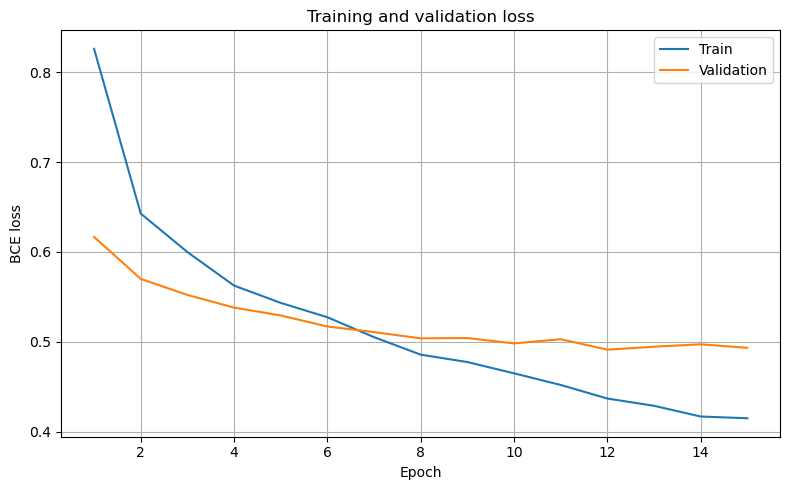

Loss plot saved to: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_loss.png


In [130]:
epochs_completed = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, history["train_loss"], label="Train")
plt.plot(epochs_completed, history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.grid()

# Save before show so the stored figure is not empty in some backends.
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss plot saved to:", loss_plot_path)


## Reload and evaluate the best checkpoint

The model from the lowest validation loss is reloaded before the final report. AUC and average precision are calculated from probabilities, not from thresholded 0/1 predictions.


In [131]:
checkpoint = torch.load(checkpoint_path, map_location=device)

# ResNet18 / ResNet34
model = build_model(
    num_classes=checkpoint["num_classes"],
    architecture=checkpoint.get("architecture", "resnet18"),
    fine_tune_layer1=checkpoint.get("fine_tune_layer1", False),
    fine_tune_layer2=checkpoint.get("fine_tune_layer2", False),
    fine_tune_layer3=checkpoint.get("fine_tune_layer3", False),
    fine_tune_layer4=checkpoint.get("fine_tune_layer4", True),
    full_fine_tuning=checkpoint.get("full_fine_tuning", True),
    pretrained=False).to(device)

'''
model = build_model_densenet121(
    NUM_CLASSES,
    fine_tune_block3=FINE_TUNE_BLOCK3,
    fine_tune_block4=FINE_TUNE_BLOCK4,
    pretrained=True,
).to(device)
'''

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

criterion = nn.BCEWithLogitsLoss(pos_weight=checkpoint["pos_weight"].to(device))
#criterion = FocalLoss(alpha=checkpoint["focal_alpha"],gamma=checkpoint["focal_gamma"])

print(
    f"Loaded best model from epoch {checkpoint['epoch']} "
    f"with validation loss {checkpoint['best_val_macro_ap']:.4f}."
)


Loaded best model from epoch 14 with validation loss 0.5383.


In [132]:
(
    val_metrics,
    val_probabilities,
    val_predictions,
    val_targets,
    val_auc,
    val_ap) = evaluate(
    model,
    val_loader,
    criterion,
    device,
    thresholds=0.5)

metric_table = pd.DataFrame([val_metrics],index=[ "Validation"])

display(metric_table)


,hamming_accuracy,micro_f1,macro_f1,macro_auc,macro_average_precision,loss
Validation,0.859198,0.56807,0.498217,0.92074,0.538293,0.497187


In [133]:
def evaluate_no_finding(targets,predictions,dataset_name,print_report=True):
    true_no_finding = (targets.sum(axis=1) == 0).astype(int)

    predicted_no_finding = (predictions.sum(axis=1) == 0).astype(int)

    precision, recall, f1, support = (
        precision_recall_fscore_support(true_no_finding,predicted_no_finding,labels=[0, 1],zero_division=0))

    results = pd.DataFrame({
        "dataset": [dataset_name, dataset_name],
        "class": [
            "At least one finding",
            "No finding"],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int),
        "accuracy": [accuracy_score(true_no_finding,predicted_no_finding)] * 2
    })

    if print_report:
        print(f"\nNo-finding evaluation: {dataset_name}")

        print(
            classification_report(
                true_no_finding,
                predicted_no_finding,
                labels=[0, 1],
                target_names=[
                    "At least one finding",
                    "No finding"],
                zero_division=0,
            )
        )

    return results

## Select class-specific thresholds on the validation set

The thresholds below maximize F1 on the validation set. They may be useful for later inference, but performance reported on the **same validation set** is optimistic because that set was used to choose the thresholds.

For an unbiased final evaluation, apply these thresholds to a separate labeled test set.


In [134]:
best_thresholds = find_best_f1_thresholds(val_targets,val_probabilities)
(
    tuned_val_metrics,
    tuned_val_predictions,
    tuned_val_auc,
    tuned_val_ap) = calculate_metrics(
    val_targets,
    val_probabilities,
    thresholds=best_thresholds)

threshold_table = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": class_names,
    "threshold": best_thresholds})

display(threshold_table)
display(pd.DataFrame([tuned_val_metrics], index=["Validation, tuned thresholds"]))

# Store the thresholds in the existing checkpoint.
checkpoint["class_thresholds"] = torch.tensor(best_thresholds)
torch.save(checkpoint, checkpoint_path)

print("Thresholds added to:", checkpoint_path)


,class_id,class_name,threshold
0,0,Aortic enlargement,0.60
1,1,Atelectasis,0.65
2,2,Calcification,0.65
3,3,Cardiomegaly,0.75
4,4,Consolidation,0.70
5,5,ILD,0.80
6,6,Infiltration,0.80
7,7,Lung Opacity,0.85
8,8,Nodule/Mass,0.75
9,9,Other lesion,0.70


,hamming_accuracy,micro_f1,macro_f1,macro_auc,macro_average_precision
"Validation, tuned thresholds",0.910076,0.63045,0.546516,0.92074,0.538293


Thresholds added to: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_checkpoint.pth


In [135]:
(
    test_metrics,
    test_probabilities,
    test_predictions,
    test_targets,
    test_auc,
    test_ap) = evaluate(
    model,
    test_loader,
    criterion,
    device,
    thresholds=best_thresholds)

test_metrics_table = pd.DataFrame([test_metrics],index=["Test"])
display(test_metrics_table)

test_class_report = create_per_class_report(
    test_targets,
    test_predictions,
    test_auc,
    test_ap,
    class_names)

display(test_class_report)
print(classification_report(
        test_targets,
        test_predictions,
        target_names=class_names,
        zero_division=0
    )
)


,hamming_accuracy,micro_f1,macro_f1,macro_auc,macro_average_precision,loss
Test,0.907465,0.618939,0.527237,0.917641,0.539349,0.507673


,class_id,class_name,support,precision,recall,f1,roc_auc,average_precision
0,0,Aortic enlargement,356,0.770335,0.904494,0.832041,0.963954,0.911926
1,1,Atelectasis,23,0.333333,0.391304,0.360000,0.925471,0.295052
2,2,Calcification,54,0.196850,0.462963,0.276243,0.868897,0.221109
3,3,Cardiomegaly,262,0.804598,0.801527,0.803059,0.964486,0.872281
4,4,Consolidation,53,0.482759,0.528302,0.504505,0.942264,0.502639
5,5,ILD,50,0.323944,0.460000,0.380165,0.916634,0.451506
6,6,Infiltration,81,0.517647,0.543210,0.530120,0.927043,0.563332
7,7,Lung Opacity,170,0.644444,0.511765,0.570492,0.915265,0.644369
8,8,Nodule/Mass,108,0.309783,0.527778,0.390411,0.872390,0.365507
9,9,Other lesion,148,0.330303,0.736486,0.456067,0.870553,0.423743


                    precision    recall  f1-score   support

Aortic enlargement       0.77      0.90      0.83       356
       Atelectasis       0.33      0.39      0.36        23
     Calcification       0.20      0.46      0.28        54
      Cardiomegaly       0.80      0.80      0.80       262
     Consolidation       0.48      0.53      0.50        53
               ILD       0.32      0.46      0.38        50
      Infiltration       0.52      0.54      0.53        81
      Lung Opacity       0.64      0.51      0.57       170
       Nodule/Mass       0.31      0.53      0.39       108
      Other lesion       0.33      0.74      0.46       148
  Pleural effusion       0.76      0.54      0.63       136
Pleural thickening       0.55      0.83      0.66       245
      Pneumothorax       0.26      0.50      0.34        14
Pulmonary fibrosis       0.56      0.75      0.64       204

         micro avg       0.55      0.71      0.62      1904
         macro avg       0.49      0.6

In [136]:

tuned_val_no_finding_results = evaluate_no_finding(
    val_targets,
    tuned_val_predictions,
    "Validation, tuned thresholds")

test_no_finding_results = evaluate_no_finding(
    test_targets,
    test_predictions,
    "Test, validation thresholds")


no_finding_results = pd.concat(
    [
        tuned_val_no_finding_results,
        test_no_finding_results,
    ],ignore_index=True)

no_finding_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_no_finding_metrics.csv",)

no_finding_results.to_csv(no_finding_path,index=False,)

print("Saved No-finding results:", no_finding_path)


No-finding evaluation: Validation, tuned thresholds
                      precision    recall  f1-score   support

At least one finding       0.90      0.93      0.92       506
          No finding       0.96      0.93      0.94       780

            accuracy                           0.93      1286
           macro avg       0.93      0.93      0.93      1286
        weighted avg       0.93      0.93      0.93      1286


No-finding evaluation: Test, validation thresholds
                      precision    recall  f1-score   support

At least one finding       0.87      0.94      0.90       501
          No finding       0.96      0.91      0.93       785

            accuracy                           0.92      1286
           macro avg       0.91      0.92      0.92      1286
        weighted avg       0.92      0.92      0.92      1286

Saved No-finding results: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_no_finding_metrics.csv


In [137]:
tuned_val_class_report = create_per_class_report(
    val_targets,
    tuned_val_predictions,
    tuned_val_auc,
    tuned_val_ap,
    class_names)

display(tuned_val_class_report)

print(
    classification_report(
        val_targets,
        tuned_val_predictions,
        target_names=class_names,
        zero_division=0,
    )
)

,class_id,class_name,support,precision,recall,f1,roc_auc,average_precision
0,0,Aortic enlargement,360,0.754717,0.888889,0.816327,0.958291,0.883430
1,1,Atelectasis,23,0.294118,0.434783,0.350877,0.886055,0.280813
2,2,Calcification,65,0.248120,0.507692,0.333333,0.880086,0.294197
3,3,Cardiomegaly,266,0.811388,0.857143,0.833638,0.966914,0.890938
4,4,Consolidation,43,0.454545,0.581395,0.510204,0.945050,0.405925
5,5,ILD,54,0.463768,0.592593,0.520325,0.935170,0.529495
6,6,Infiltration,74,0.440000,0.594595,0.505747,0.936301,0.460780
7,7,Lung Opacity,169,0.695652,0.568047,0.625407,0.927394,0.681821
8,8,Nodule/Mass,99,0.319767,0.555556,0.405904,0.876150,0.352045
9,9,Other lesion,140,0.310559,0.714286,0.432900,0.851309,0.366405


                    precision    recall  f1-score   support

Aortic enlargement       0.75      0.89      0.82       360
       Atelectasis       0.29      0.43      0.35        23
     Calcification       0.25      0.51      0.33        65
      Cardiomegaly       0.81      0.86      0.83       266
     Consolidation       0.45      0.58      0.51        43
               ILD       0.46      0.59      0.52        54
      Infiltration       0.44      0.59      0.51        74
      Lung Opacity       0.70      0.57      0.63       169
       Nodule/Mass       0.32      0.56      0.41        99
      Other lesion       0.31      0.71      0.43       140
  Pleural effusion       0.74      0.59      0.65       138
Pleural thickening       0.59      0.82      0.69       256
      Pneumothorax       0.29      0.55      0.37        11
Pulmonary fibrosis       0.54      0.68      0.60       205

         micro avg       0.56      0.73      0.63      1903
         macro avg       0.50      0.6

In [138]:
baseline_metrics = pd.DataFrame(
    [
        val_metrics,
        tuned_val_metrics,
        test_metrics],
    index=[
        "Validation, threshold 0.5",
        "Validation, tuned thresholds",
        "Test, validation thresholds"])

metrics_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_metrics.csv")
baseline_metrics.to_csv(metrics_path)

test_class_report_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_test_per_class.csv")

test_class_report.to_csv(test_class_report_path,index=False)

threshold_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_thresholds.csv")

threshold_table.to_csv(threshold_path,index=False)

history_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_history.csv")

pd.DataFrame(history).to_csv(history_path,index=False)

print("Saved metrics:", metrics_path)
print("Saved per-class results:", test_class_report_path)
print("Saved thresholds:", threshold_path)
print("Saved training history:", history_path)

Saved metrics: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_metrics.csv
Saved per-class results: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_test_per_class.csv
Saved thresholds: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_thresholds.csv
Saved training history: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_history.csv


In [139]:
baseline_config = {
    "experiment_name": EXPERIMENT_NAME,
    "architecture": ARCHITECTURE,
    "pretrained_on_imagenet": True,
    "input_channels": 1,
    "number_of_outputs": NUM_CLASSES,
    "no_finding_handling": (
        "Excluded as model output and derived when no disease "
        "class exceeds its threshold"),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": NUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "fine_tune_layer4": FINE_TUNE_LAYER4,
    "fine_tune_layer3": FINE_TUNE_LAYER3,
    "fine_tune_layer2": FINE_TUNE_LAYER2,
    "fine_tune_layer1": FINE_TUNE_LAYER1,
    "full_fine_tuning": FULL_FINE_TUNING,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "backbone_learning_rate": BACKBONE_LEARNING_RATE,
    "EARLY_BACKBONE_LEARNING_RATE": EARLY_BACKBONE_LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "loss": "BCEWithLogitsLoss with pos_weight",
    "maximum_pos_weight": MAX_POS_WEIGHT,
    "checkpoint_selection": "lowest validation loss",
    "threshold_selection": "maximum class-specific validation F1",
    "random_state": RANDOM_STATE,
    "train_images": len(train_ids),
    "validation_images": len(val_ids),
    "test_images": len(test_ids)}

config_path = os.path.join(output_dir,f"{EXPERIMENT_NAME}_config.json")

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(baseline_config,file,indent=4)

print("Saved configuration:", config_path)

Saved configuration: results\outputs\B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_config.json


In [146]:
# compute mean, std for metrics of all seeds for final model

metrics_paths = [
    "results/outputs/B14_efficientnetB0_earlyLR_full_320px_posweight10_42_macroAP_metrics.csv",
    "results/outputs/B14_efficientnetB0_earlyLR_full_320px_posweight10_43_macroAP_metrics.csv",
    "results/outputs/B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_metrics.csv",
]

seed_tables = [pd.read_csv(p, index_col=0) for p in metrics_paths]

combined = pd.concat(seed_tables, keys=range(len(seed_tables)), names=["seed_run", "row"])

mean_table = combined.groupby(level="row").mean()
std_table = combined.groupby(level="row").std()

summary_table = mean_table.copy()
for col in mean_table.columns:
    summary_table[col] = mean_table[col].map("{:.4f}".format) + " ± " + std_table[col].map("{:.4f}".format)

summary_table = summary_table.reindex(seed_tables[0].index)
summary_table = summary_table.T
display(summary_table)

# export latex code
latex_table = summary_table.to_latex(
    escape=False,
    index=True
)
print(latex_table)

,"Validation, threshold 0.5","Validation, tuned thresholds","Test, validation thresholds"
hamming_accuracy,0.8674 ± 0.0084,0.9084 ± 0.0047,0.9061 ± 0.0054
micro_f1,0.5800 ± 0.0113,0.6312 ± 0.0081,0.6183 ± 0.0088
macro_f1,0.5063 ± 0.0072,0.5514 ± 0.0047,0.5263 ± 0.0019
macro_auc,0.9219 ± 0.0012,0.9219 ± 0.0012,0.9194 ± 0.0022
macro_average_precision,0.5413 ± 0.0051,0.5413 ± 0.0051,0.5444 ± 0.0050
loss,0.4947 ± 0.0028,nan ± nan,0.5060 ± 0.0014


\begin{tabular}{llll}
\toprule
 & Validation, threshold 0.5 & Validation, tuned thresholds & Test, validation thresholds \\
\midrule
hamming_accuracy & 0.8674 ± 0.0084 & 0.9084 ± 0.0047 & 0.9061 ± 0.0054 \\
micro_f1 & 0.5800 ± 0.0113 & 0.6312 ± 0.0081 & 0.6183 ± 0.0088 \\
macro_f1 & 0.5063 ± 0.0072 & 0.5514 ± 0.0047 & 0.5263 ± 0.0019 \\
macro_auc & 0.9219 ± 0.0012 & 0.9219 ± 0.0012 & 0.9194 ± 0.0022 \\
macro_average_precision & 0.5413 ± 0.0051 & 0.5413 ± 0.0051 & 0.5444 ± 0.0050 \\
loss & 0.4947 ± 0.0028 & nan ± nan & 0.5060 ± 0.0014 \\
\bottomrule
\end{tabular}



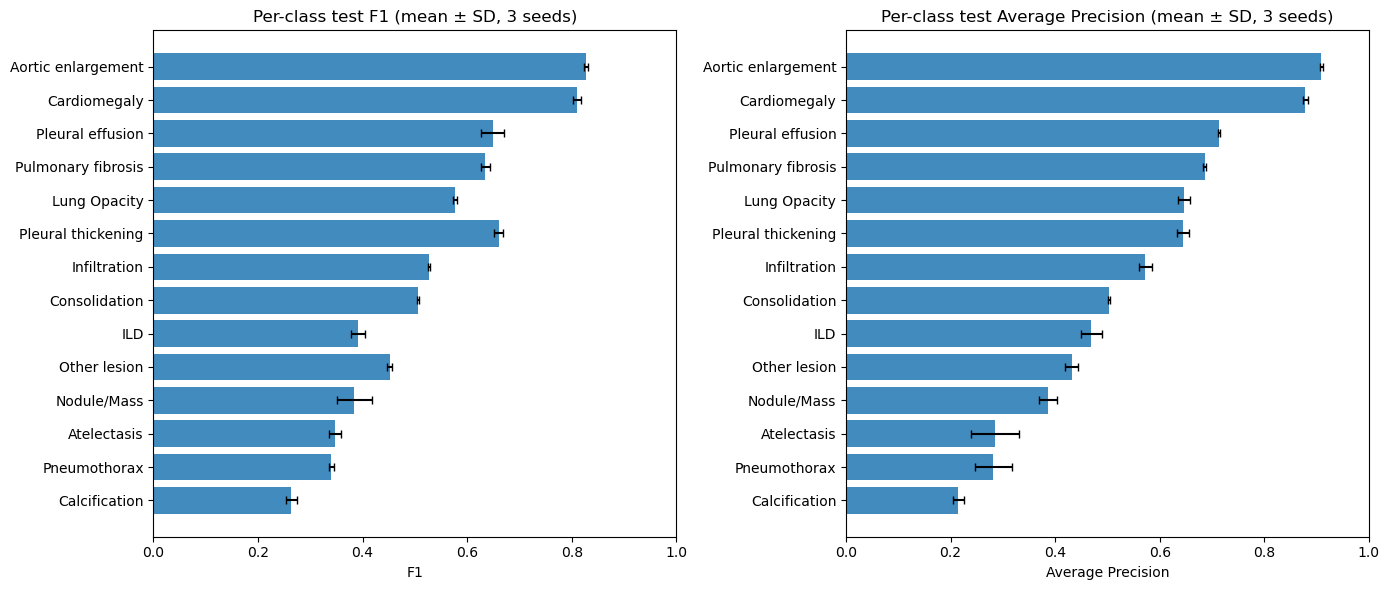

In [156]:
# per class metrics 

class_metrics_paths = [
    "results/outputs/B14_efficientnetB0_earlyLR_full_320px_posweight10_42_macroAP_test_per_class.csv",
    "results/outputs/B14_efficientnetB0_earlyLR_full_320px_posweight10_43_macroAP_test_per_class.csv",
    "results/outputs/B14_efficientnetB0_earlyLR_full_320px_posweight10_44_macroAP_test_per_class.csv",
]

per_class_reports = [pd.read_csv(p, index_col=0) for p in class_metrics_paths]

# which metrics?
f1_matrix = np.stack([r["f1"].values for r in per_class_reports])   # shape (3, 14)
ap_matrix = np.stack([r["average_precision"].values for r in per_class_reports])

f1_mean, f1_std = f1_matrix.mean(axis=0), f1_matrix.std(axis=0)
ap_mean, ap_std = ap_matrix.mean(axis=0), ap_matrix.std(axis=0)

# wonach sortieren?
class_names_sorted_idx = np.argsort(ap_mean)  # sort ascending for a nicer horizontal chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, mean, std, title in zip(axes, [f1_mean, ap_mean], [f1_std, ap_std], ["F1", "Average Precision"]):
    sorted_mean = mean[class_names_sorted_idx]
    sorted_std = std[class_names_sorted_idx]
    sorted_names = np.array(class_names)[class_names_sorted_idx]

    ax.barh(sorted_names, sorted_mean, xerr=sorted_std, capsize=3, alpha=0.85) # , color="#4C72B0"
    ax.set_xlabel(title)
    ax.set_xlim(0, 1)
    ax.set_title(f"Per-class test {title} (mean ± SD, 3 seeds)")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "per_class_f1_ap_across_seeds.png"), dpi=200, bbox_inches="tight")
plt.show()

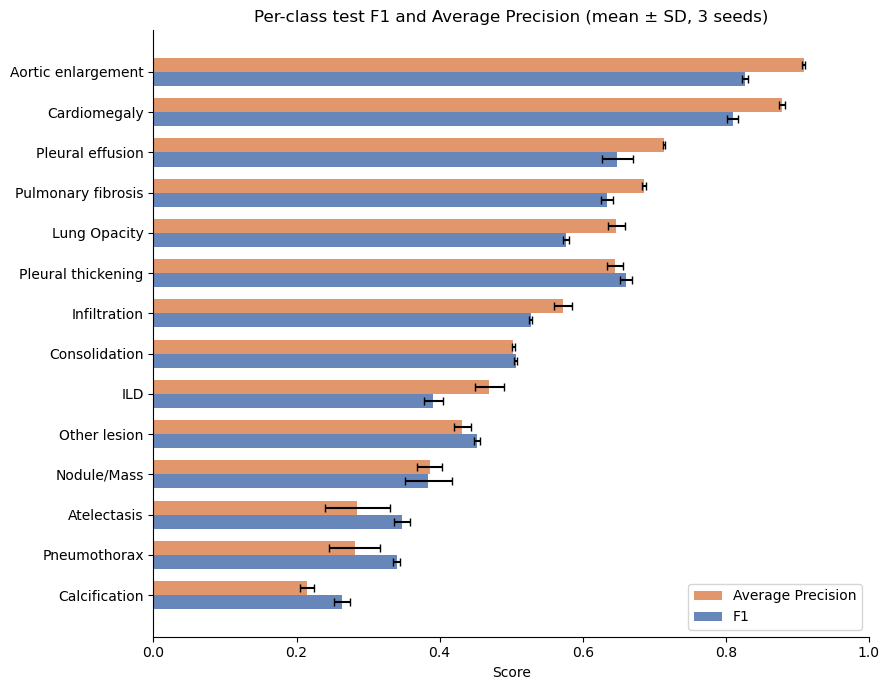

In [164]:
sorted_idx = np.argsort(ap_mean)
f1_mean_sorted, f1_std_sorted = f1_mean[sorted_idx], f1_std[sorted_idx]
ap_mean_sorted, ap_std_sorted = ap_mean[sorted_idx], ap_std[sorted_idx]
names_sorted = np.array(class_names)[sorted_idx]

n_classes = len(names_sorted)
y_positions = np.arange(n_classes)
bar_height = 0.35

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(y_positions + bar_height/2, ap_mean_sorted, height=bar_height,
        xerr=ap_std_sorted, capsize=3, color="#DD8452", alpha=0.85, label="Average Precision")

ax.barh(y_positions - bar_height/2, f1_mean_sorted, height=bar_height,
        xerr=f1_std_sorted, capsize=3, color="#4C72B0", alpha=0.85, label="F1")

ax.set_yticks(y_positions)
ax.set_yticklabels(names_sorted)
ax.set_xlabel("Score")
ax.set_xlim(0, 1)
ax.set_title("Per-class test F1 and Average Precision (mean ± SD, 3 seeds)")
ax.legend(loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "per_class_f1_ap_grouped.png"), dpi=200, bbox_inches="tight")
plt.show()

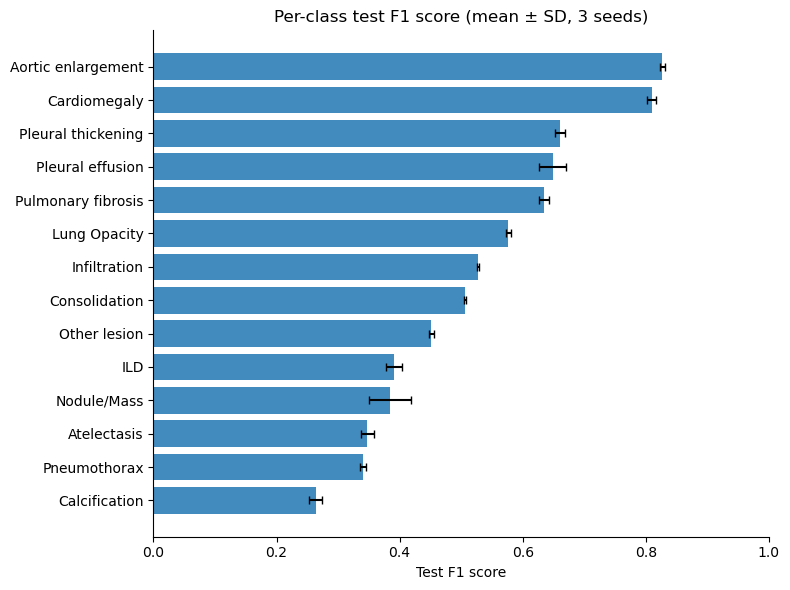

In [155]:
f1_matrix = np.stack([r["f1"].values for r in per_class_reports])
f1_mean, f1_std = f1_matrix.mean(axis=0), f1_matrix.std(axis=0)

sorted_idx = np.argsort(f1_mean)
sorted_mean = f1_mean[sorted_idx]
sorted_std = f1_std[sorted_idx]
sorted_names = np.array(class_names)[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sorted_names, sorted_mean, xerr=sorted_std, capsize=3, alpha=0.85)

ax.set_xlabel("Test F1 score")
ax.set_xlim(0, 1)
ax.set_title("Per-class test F1 score (mean ± SD, 3 seeds)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "per_class_f1_across_seeds.png"), dpi=200, bbox_inches="tight")
plt.show()

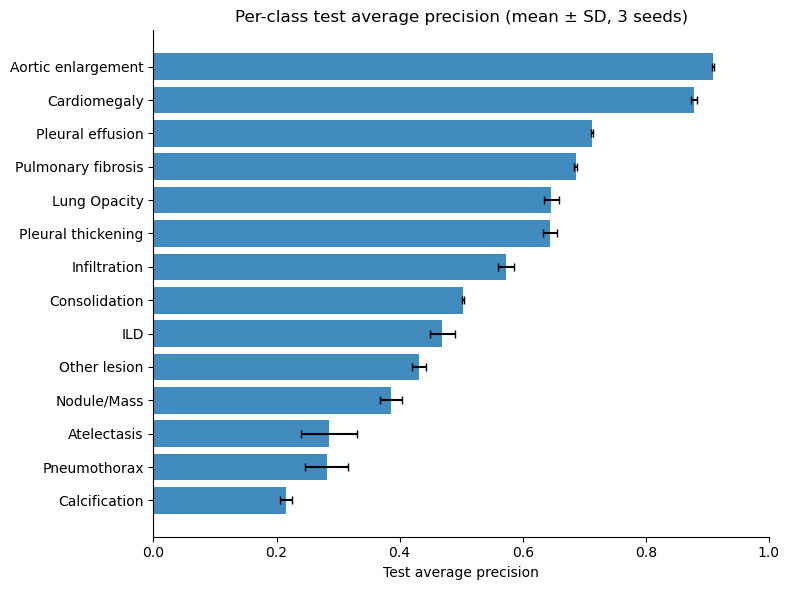

In [154]:
ap_matrix = np.stack([r["average_precision"].values for r in per_class_reports])
ap_mean, ap_std = ap_matrix.mean(axis=0), ap_matrix.std(axis=0)

sorted_idx = np.argsort(ap_mean)
sorted_mean = ap_mean[sorted_idx]
sorted_std = ap_std[sorted_idx]
sorted_names = np.array(class_names)[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sorted_names, sorted_mean, xerr=sorted_std, capsize=3, alpha=0.85)

ax.set_xlabel("Test average precision")
ax.set_xlim(0, 1)
ax.set_title("Per-class test average precision (mean ± SD, 3 seeds)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "per_class_ap_across_seeds.png"), dpi=200, bbox_inches="tight")
plt.show()

## Methodological notes

- The bounding boxes remain unused because this notebook addresses image-level multi-label classification.
- `No finding` is excluded as a separate model output.
- Images annotated only as `No finding` remain in the dataset and are represented by an all-zero disease-label vector.
- During inference, `No finding` is derived when none of the 14 pathological classes exceeds its class-specific threshold.
- A fixed 70/15/15 training, validation, and test split is used.
- The split approximately balances the prevalence of all 14 pathological classes and the derived `No finding` category.
- The validation set is used for early stopping, checkpoint selection, and class-specific threshold selection.
- The test set remains untouched until final evaluation.
- The split approximates multi-label stratification by matching class prevalences.
- Class imbalance is addressed with training-set `pos_weight`.
- AUC and average precision use continuous probabilities.
- Macro F1, micro F1, macro AUC, macro average precision and Hamming accuracy are reported separately.
- Light augmentation, weight decay, learning-rate reduction and early stopping reduce overfitting.
- The best model is reloaded before final evaluation.


# Baseline setup
Experiment:
B0_resnet18_head_only

Architecture:
ImageNet-pretrained ResNet-18

Trainable parameters:
classification head only

Outputs:
14 pathological classes

No finding:
derived from an all-zero prediction

Split:
70% training
15% validation
15% test

Loss:
weighted BCEWithLogitsLoss

Checkpoint:
lowest validation loss

Thresholds:
class-specific F1 optimization on validation

Final evaluation:
unchanged validation thresholds applied to test